# Proyecto Final — Sistema de Recomendación E-commerce
## MetricEdge S.A.S — EDA y Preparación de Datos (Sprint 1)

**Dataset:** [E-commerce Sales & Customer Analytics (150k)](https://www.kaggle.com/datasets/datascikhan/e-commerce-sales-and-customer-analytics) — Kaggle

**Objetivo del notebook:** entender la estructura y calidad de los datos, construir la matriz de
interacciones usuario-producto y dejar documentadas las decisiones de tratamiento que van a
alimentar la ingeniería de características y el modelado (baseline de popularidad, filtrado
colaborativo item-based y modelo supervisado de probabilidad de compra/recompra).

**Contenido:**
1. Entendimiento de los datos (esquema y relación entre tablas)
2. Calidad de datos (nulos, duplicados, consistencia de claves, outliers)
3. Construcción de la matriz usuario-producto e interacciones
4. Análisis exploratorio con visualizaciones clave
5. Hallazgos y decisiones para los próximos pasos


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titleweight'] = 'bold'


## 1. Entendimiento de los datos

El dataset viene separado en 4 archivos. Los cargamos y revisamos su estructura y cómo se relacionan entre sí.

In [11]:
customer = pd.read_csv('../data/raw/customer_master.csv')
product  = pd.read_csv('../data/raw/product_catalog.csv')
order_items = pd.read_csv('../data/raw/order_items.csv')
sales = pd.read_csv('../data/raw/ecommerce_sales_customer_analytics_150k.csv')
sales['order_date'] = pd.to_datetime(sales['order_date'])

for name, df in [('customer_master', customer), ('product_catalog', product),
                  ('order_items', order_items), ('sales (nivel orden)', sales)]:
    print(f'{name:28s} -> {df.shape[0]:>7,} filas x {df.shape[1]:>2} columnas')


customer_master              ->  25,000 filas x 11 columnas
product_catalog              ->   1,175 filas x  9 columnas
order_items                  -> 397,569 filas x 12 columnas
sales (nivel orden)          -> 138,116 filas x 46 columnas


**Esquema y relación entre tablas:**

- `customer_master` (25.000 filas): 1 fila por cliente (`customer_id`) — demografía y CAC.
- `product_catalog` (1.175 filas): 1 fila por producto (`product_id`) — categoría, marca, precio, rating del producto.
- `order_items` (397.569 filas): 1 fila por **línea de producto dentro de una orden** (`order_id` + `product_id`) — es la tabla que nos da la interacción usuario-producto una vez cruzada con `sales`.
- `sales` (138.116 filas): 1 fila por **orden** (`order_id`) — contiene `customer_id`, fecha, estado de la orden, canal, pagos, devoluciones, rating y sentimiento de la reseña, CLV, etc.

Es decir: `sales` es la cabecera de la orden (1 por orden) y `order_items` es el detalle (varios productos por orden, ~2.9 productos por orden en promedio). Para armar la matriz usuario-producto hay que **unir `order_items` con `sales` por `order_id`** para traer el `customer_id`.

In [12]:
orders_per_key = order_items.merge(sales[['order_id']], on='order_id', how='outer', indicator=True)
print('Chequeo de integridad referencial order_items <-> sales (order_id):')
print(orders_per_key['_merge'].value_counts())

items_per_order = order_items.groupby('order_id').size()
print()
print('Productos (líneas) por orden:')
print(items_per_order.describe())


Chequeo de integridad referencial order_items <-> sales (order_id):
_merge
both          397569
left_only          0
right_only         0
Name: count, dtype: int64

Productos (líneas) por orden:
count    138116.000000
mean          2.878515
std           1.512076
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
max          18.000000
dtype: float64


## 2. Calidad de datos

Revisamos nulos, duplicados y outliers en cada tabla, siguiendo los criterios que pide la consigna
(valores faltantes, desbalance, consistencia de claves).

In [13]:
print('--- % de nulos por tabla (solo columnas con nulos) ---')
for name, df in [('customer_master', customer), ('product_catalog', product),
                  ('order_items', order_items), ('sales', sales)]:
    nulls = (df.isnull().mean()*100).round(2)
    nulls = nulls[nulls > 0].sort_values(ascending=False)
    print(f'\n{name}:')
    print(nulls.to_string() if len(nulls) else '  sin nulos')


--- % de nulos por tabla (solo columnas con nulos) ---

customer_master:
  sin nulos

product_catalog:
  sin nulos

order_items:
  sin nulos

sales:
return_status              93.15
return_reason              93.15
coupon_code                80.01
campaign_name              60.26
delivery_days              17.78
customer_rating            17.78
estimated_delivery_days    17.78
customer_review            17.78
review_sentiment           17.78


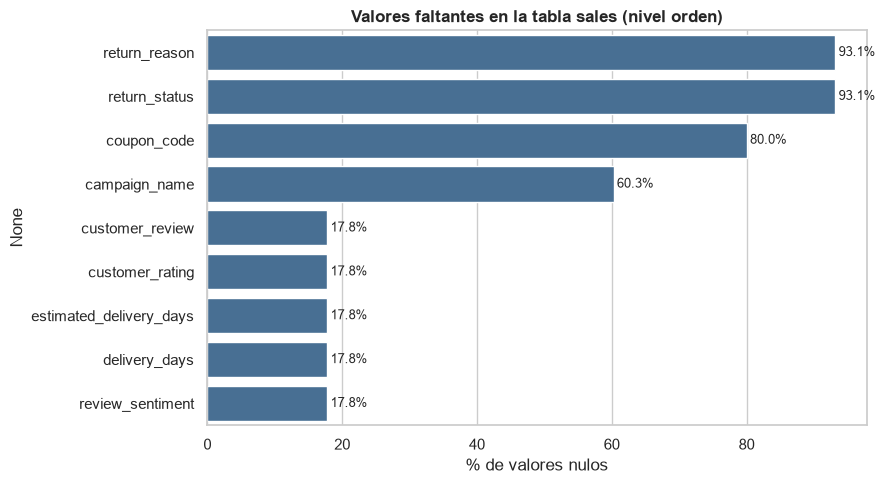

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
null_pct = (sales.isnull().mean()*100).sort_values(ascending=False)
null_pct = null_pct[null_pct > 0]
sns.barplot(x=null_pct.values, y=null_pct.index, ax=ax, color='#3b6fa0')
ax.set_xlabel('% de valores nulos')
ax.set_title('Valores faltantes en la tabla sales (nivel orden)')
for i, v in enumerate(null_pct.values):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()


**Lectura de los nulos — son en su mayoría "nulos estructurales", no aleatorios:**

- `return_status` / `return_reason` (93.15%): nulo cuando la orden **no fue devuelta**. No se debe imputar; se recategoriza como `"No devuelto"`.
- `delivery_days`, `estimated_delivery_days`, `customer_rating`, `review_sentiment`, `customer_review` (17.78% cada una): nulo cuando la orden **no está en estado `Completed`** (no hubo entrega ni reseña posible). Se trata como categoría/estado, no como dato faltante a imputar.
- `campaign_name` (60.26%) y `coupon_code` (80.01%): nulo cuando la compra **no vino de una campaña o no usó cupón**. Se recategoriza como `"Sin campaña"` / `"Sin cupón"`.

Conclusión: no hace falta imputación estadística (media/mediana) en estas columnas — son ausencias con significado de negocio.

In [15]:
print('--- Duplicados ---')
print('customer_master — customer_id duplicado:', customer.customer_id.duplicated().sum())
print('product_catalog — product_id duplicado:', product.product_id.duplicated().sum())
print('sales — order_id duplicado:', sales.order_id.duplicated().sum())
print('order_items — fila completa duplicada:', order_items.duplicated().sum())
dup_pairs = order_items.duplicated(subset=['order_id', 'product_id']).sum()
print('order_items — mismo (order_id, product_id) repetido como línea aparte:', dup_pairs)


--- Duplicados ---
customer_master — customer_id duplicado: 0
product_catalog — product_id duplicado: 0
sales — order_id duplicado: 0
order_items — fila completa duplicada: 0
order_items — mismo (order_id, product_id) repetido como línea aparte: 87


Las claves primarias (`customer_id`, `product_id`, `order_id`) están limpias, sin duplicados. El único
caso a tratar son las **87 líneas de `order_items`** donde el mismo producto aparece dos veces dentro de
la misma orden como renglones separados — en la etapa de feature engineering hay que **agregarlas (sumar
`quantity`, sumar `net_sales`) antes de construir la matriz usuario-producto**, para no contar la misma
interacción dos veces.

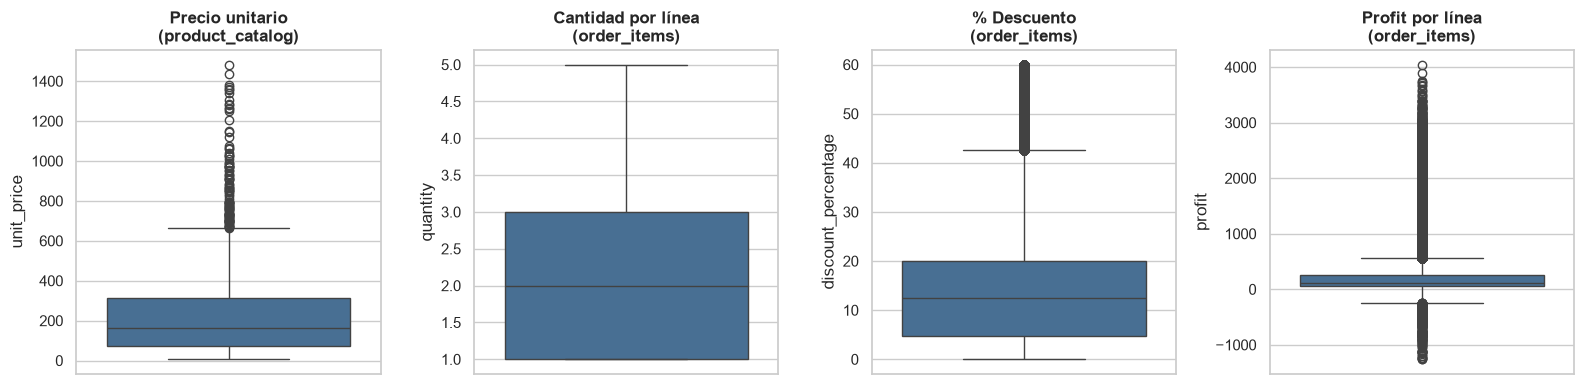

Líneas con profit negativo: 5426 (1.4% del total)
Precio unitario: min 6.31 - max 1482.95


In [16]:
num_cols = ['unit_price', 'quantity', 'discount_percentage', 'profit']
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
sns.boxplot(y=product['unit_price'], ax=axes[0], color='#3b6fa0'); axes[0].set_title('Precio unitario\n(product_catalog)')
sns.boxplot(y=order_items['quantity'], ax=axes[1], color='#3b6fa0'); axes[1].set_title('Cantidad por línea\n(order_items)')
sns.boxplot(y=order_items['discount_percentage']*100, ax=axes[2], color='#3b6fa0'); axes[2].set_title('% Descuento\n(order_items)')
sns.boxplot(y=order_items['profit'], ax=axes[3], color='#3b6fa0'); axes[3].set_title('Profit por línea\n(order_items)')
for ax in axes:
    ax.set_xlabel('')
plt.tight_layout()
plt.show()

print('Líneas con profit negativo:', (order_items.profit < 0).sum(),
      f"({(order_items.profit < 0).mean()*100:.1f}% del total)")
print('Precio unitario: min', product.unit_price.min(), '- max', product.unit_price.max())


No se observan outliers extremos ni errores evidentes de carga (precios, cantidades y descuentos
están en rangos de negocio razonables). El **profit negativo en ~4% de las líneas** no es un error: son
productos vendidos con descuento por debajo del costo — es una señal de negocio válida, no un dato a
corregir, pero conviene tenerla presente si más adelante se usa `profit` como feature.

## 3. Construcción de la matriz usuario-producto

Unimos `order_items` con `sales` para tener, por cada línea de compra, quién la hizo (`customer_id`) y
cuándo (`order_date`, `order_status`). Esta tabla es la base directa para el sistema de recomendación.

In [17]:
interactions_raw = order_items.merge(
    sales[['order_id', 'customer_id', 'order_date', 'order_status']],
    on='order_id', how='left'
)

print('Estado de las órdenes (a nivel línea de producto):')
print(interactions_raw.order_status.value_counts())
print()
print(interactions_raw.order_status.value_counts(normalize=True).mul(100).round(1).astype(str) + ' %')


Estado de las órdenes (a nivel línea de producto):
order_status
Completed    327028
Returned      27209
Cancelled     24109
Pending       19223
Name: count, dtype: int64

order_status
Completed    82.3 %
Returned      6.8 %
Cancelled     6.1 %
Pending       4.8 %
Name: proportion, dtype: str


**Decisión de tratamiento:** para que una interacción cuente como preferencia real del usuario por un
producto, vamos a construir la matriz con las órdenes en estado **`Completed` y `Returned`** (el producto
sí se compró y se recibió; una devolución sigue siendo una señal de interés inicial, aunque se puede usar
como feature de "insatisfacción"). Se **excluyen `Cancelled` y `Pending`**, porque ahí la compra no se
concretó y no refleja una preferencia confirmada — incluirlas metería ruido en el recomendador.

In [18]:
interactions = interactions_raw[interactions_raw.order_status.isin(['Completed', 'Returned'])].copy()

# Agregamos duplicados (mismo producto repetido como línea dentro de una orden)
interactions = (interactions
    .groupby(['customer_id', 'product_id', 'order_id', 'order_date', 'order_status'], as_index=False)
    .agg(quantity=('quantity', 'sum'))
)

n_users = interactions.customer_id.nunique()
n_items = interactions.product_id.nunique()
user_item_pairs = interactions.drop_duplicates(['customer_id', 'product_id']).shape[0]
sparsity = 1 - user_item_pairs / (n_users * n_items)

print(f'Interacciones válidas (Completed + Returned): {len(interactions):,}')
print(f'Usuarios únicos: {n_users:,} | Productos únicos: {n_items:,}')
print(f'Pares usuario-producto únicos: {user_item_pairs:,} de {n_users*n_items:,} celdas posibles')
print(f'Sparsity de la matriz: {sparsity*100:.2f}%  (densidad: {(1-sparsity)*100:.2f}%)')


Interacciones válidas (Completed + Returned): 354,157
Usuarios únicos: 24,838 | Productos únicos: 1,175
Pares usuario-producto únicos: 352,031 de 29,184,650 celdas posibles
Sparsity de la matriz: 98.79%  (densidad: 1.21%)


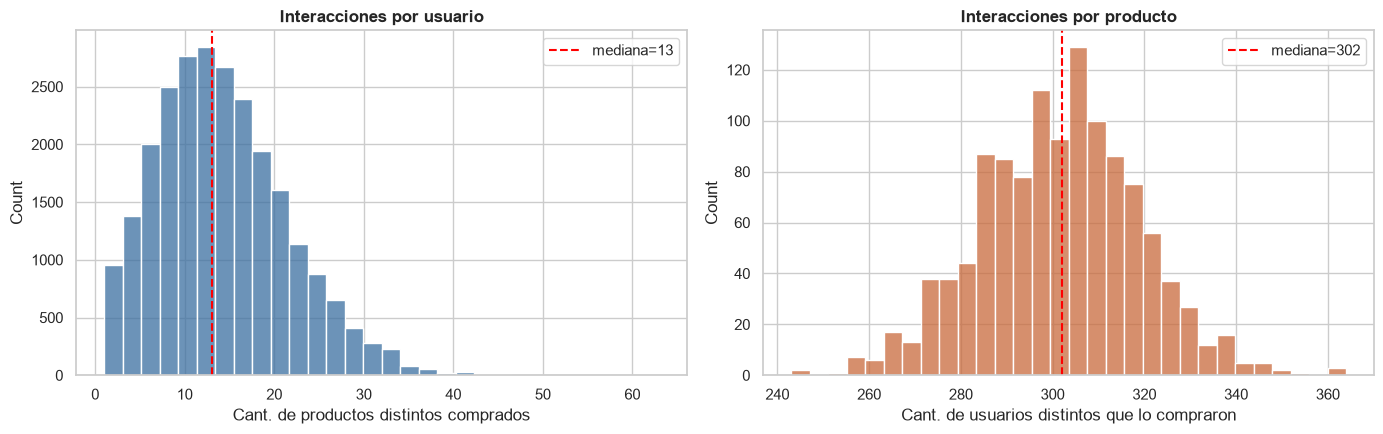

Usuarios con una sola interacción (riesgo de cold-start): 156 de 24,838 (0.63%)
Producto menos comprado: 243 | Producto más comprado: 364


In [19]:
inter_per_user = interactions.groupby('customer_id').size()
inter_per_item = interactions.groupby('product_id').size()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.histplot(inter_per_user, bins=30, ax=axes[0], color='#3b6fa0')
axes[0].set_title('Interacciones por usuario')
axes[0].set_xlabel('Cant. de productos distintos comprados')
axes[0].axvline(inter_per_user.median(), color='red', ls='--', label=f'mediana={inter_per_user.median():.0f}')
axes[0].legend()

sns.histplot(inter_per_item, bins=30, ax=axes[1], color='#c96a3c')
axes[1].set_title('Interacciones por producto')
axes[1].set_xlabel('Cant. de usuarios distintos que lo compraron')
axes[1].axvline(inter_per_item.median(), color='red', ls='--', label=f'mediana={inter_per_item.median():.0f}')
axes[1].legend()
plt.tight_layout()
plt.show()

print('Usuarios con una sola interacción (riesgo de cold-start):', (inter_per_user == 1).sum(),
      f'de {n_users:,} ({(inter_per_user==1).mean()*100:.2f}%)')
print('Producto menos comprado:', inter_per_item.min(), '| Producto más comprado:', inter_per_item.max())


**Lectura:** la matriz tiene ~98.6% de sparsity, similar a datasets clásicos de recsys (ej. MovieLens),
lo cual es manejable. El cold-start de usuario es marginal (<0.5% con una sola compra). Ahora bien, la
distribución de compras **por producto es casi uniforme** (todos los productos rondan las 280-410 compras) —
en un e-commerce real esperaríamos una cola larga (pocos productos muy populares, muchos con pocas ventas).
Esto es un **sesgo propio de datos simulados** que ya habíamos anticipado en la propuesta, y hay que
mencionarlo como limitación: un baseline de popularidad va a tener menos poder discriminante del que
tendría sobre datos reales.

## 4. Análisis exploratorio — visualizaciones clave

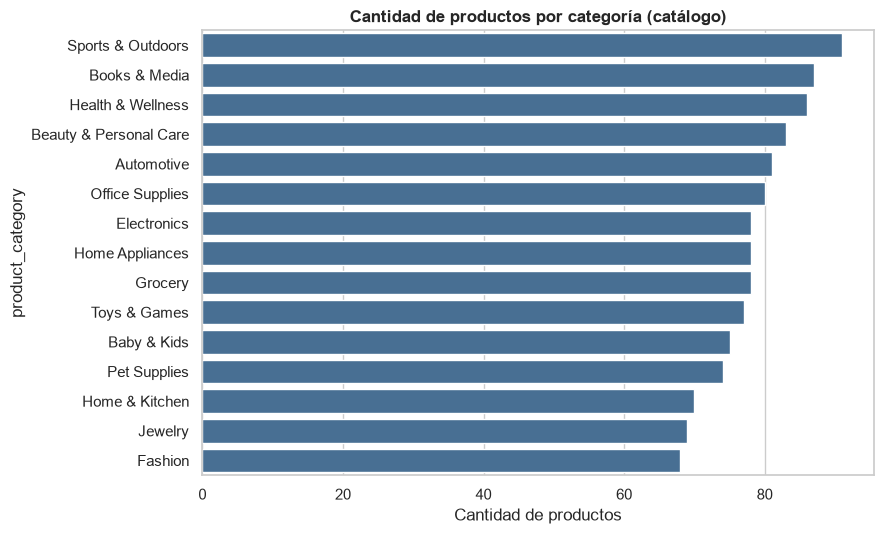

In [20]:
fig, ax = plt.subplots(figsize=(9, 5.5))
cat_counts = product.product_category.value_counts()
sns.barplot(x=cat_counts.values, y=cat_counts.index, ax=ax, color='#3b6fa0')
ax.set_title('Cantidad de productos por categoría (catálogo)')
ax.set_xlabel('Cantidad de productos')
plt.tight_layout()
plt.show()


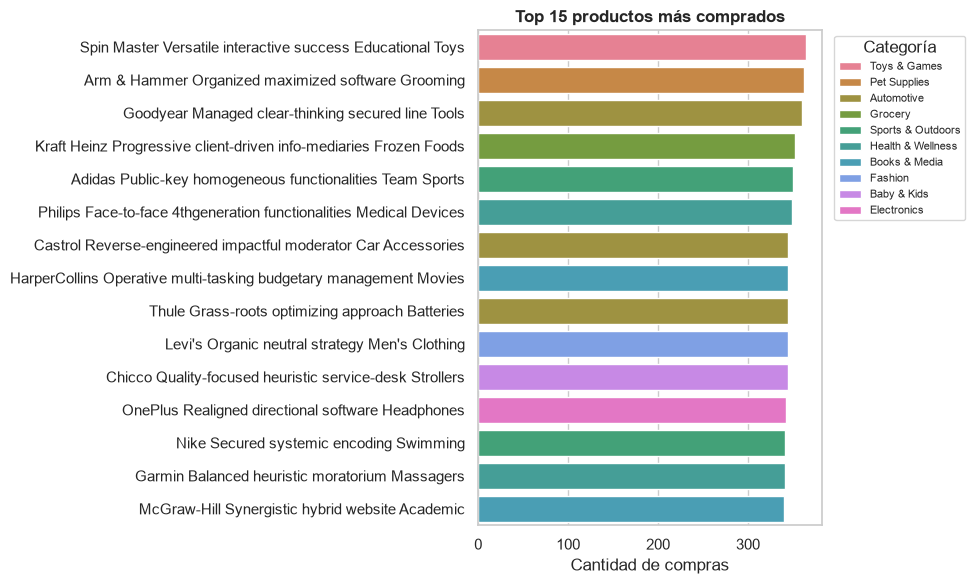

In [21]:
top_products = (interactions.merge(product[['product_id', 'product_name', 'product_category']], on='product_id')
                .groupby(['product_name', 'product_category']).size()
                .sort_values(ascending=False).head(15).reset_index(name='compras'))

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=top_products, x='compras', y='product_name', hue='product_category', dodge=False, ax=ax)
ax.set_title('Top 15 productos más comprados')
ax.set_xlabel('Cantidad de compras')
ax.set_ylabel('')
ax.legend(title='Categoría', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()


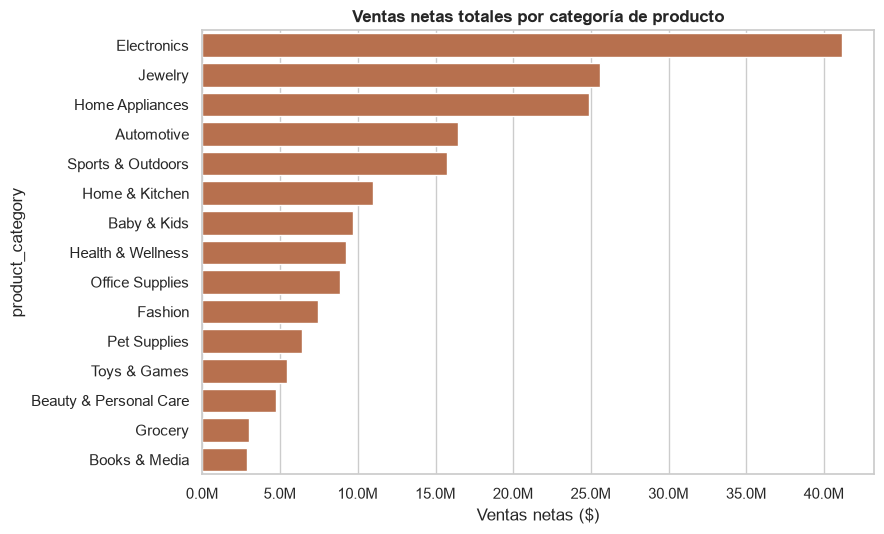

In [22]:
sales_by_cat = (order_items.merge(product[['product_id', 'product_category']], on='product_id')
                .groupby('product_category')['net_sales'].sum().sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(9, 5.5))
sns.barplot(x=sales_by_cat.values, y=sales_by_cat.index, ax=ax, color='#c96a3c')
ax.set_title('Ventas netas totales por categoría de producto')
ax.set_xlabel('Ventas netas ($)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.tight_layout()
plt.show()


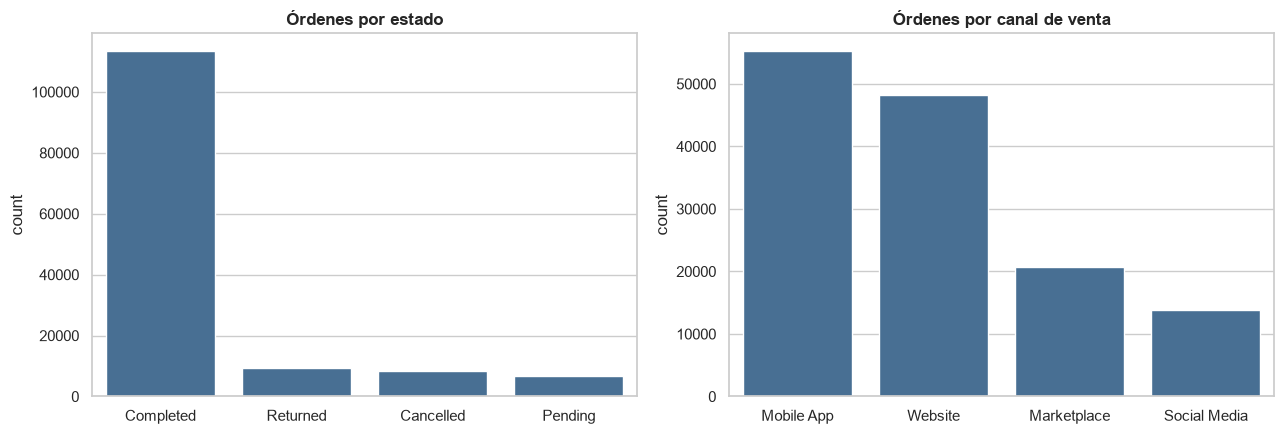

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.countplot(data=sales, x='order_status', order=sales.order_status.value_counts().index, ax=axes[0], color='#3b6fa0')
axes[0].set_title('Órdenes por estado')
axes[0].set_xlabel('')

sns.countplot(data=sales, x='sales_channel', order=sales.sales_channel.value_counts().index, ax=axes[1], color='#3b6fa0')
axes[1].set_title('Órdenes por canal de venta')
axes[1].set_xlabel('')
plt.tight_layout()
plt.show()


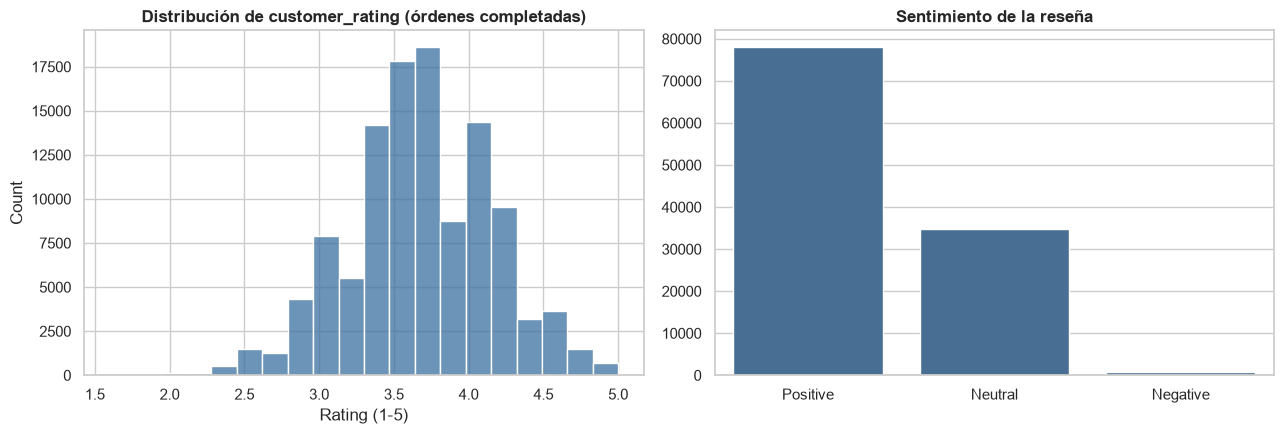

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(sales.customer_rating.dropna(), bins=20, ax=axes[0], color='#3b6fa0')
axes[0].set_title('Distribución de customer_rating (órdenes completadas)')
axes[0].set_xlabel('Rating (1-5)')

sent_counts = sales.review_sentiment.value_counts(dropna=True)
sns.barplot(x=sent_counts.index, y=sent_counts.values, ax=axes[1],
            order=['Positive', 'Neutral', 'Negative'], color='#3b6fa0')
axes[1].set_title('Sentimiento de la reseña')
axes[1].set_xlabel('')
plt.tight_layout()
plt.show()


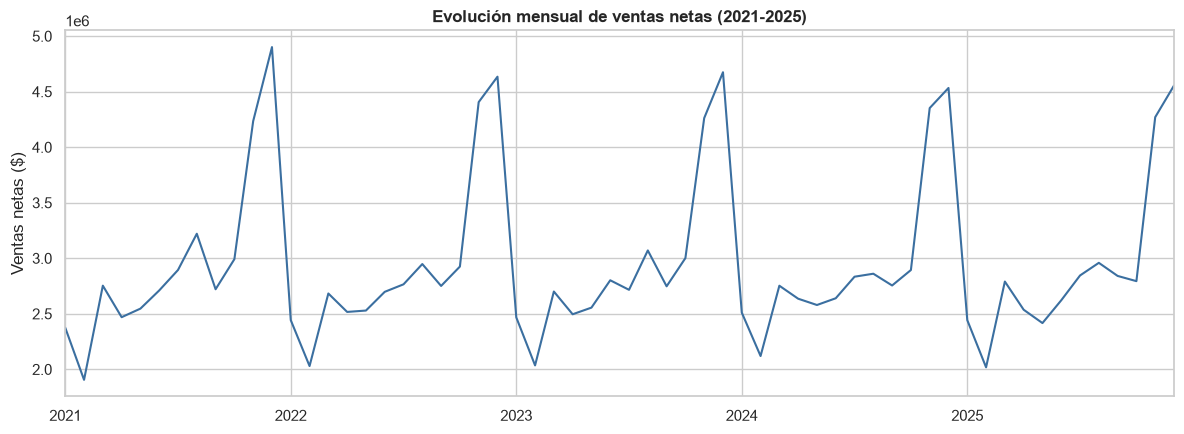

In [25]:
monthly = sales.set_index('order_date').resample('MS')['net_sales'].sum()

fig, ax = plt.subplots(figsize=(12, 4.5))
monthly.plot(ax=ax, color='#3b6fa0')
ax.set_title('Evolución mensual de ventas netas (2021-2025)')
ax.set_ylabel('Ventas netas ($)')
ax.set_xlabel('')
plt.tight_layout()
plt.show()


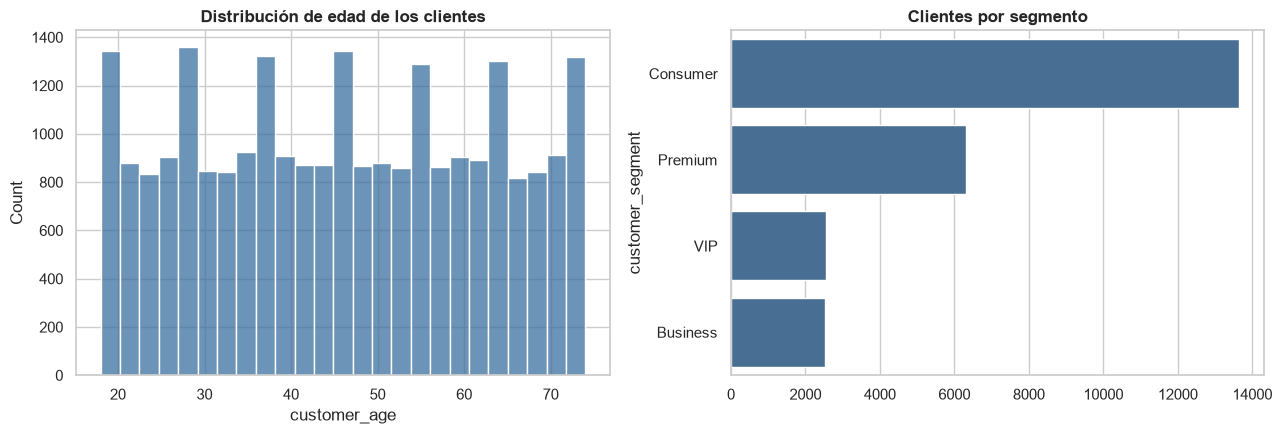

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(customer.customer_age, bins=25, ax=axes[0], color='#3b6fa0')
axes[0].set_title('Distribución de edad de los clientes')

seg_counts = customer.customer_segment.value_counts()
sns.barplot(x=seg_counts.values, y=seg_counts.index, ax=axes[1], color='#3b6fa0')
axes[1].set_title('Clientes por segmento')
plt.tight_layout()
plt.show()


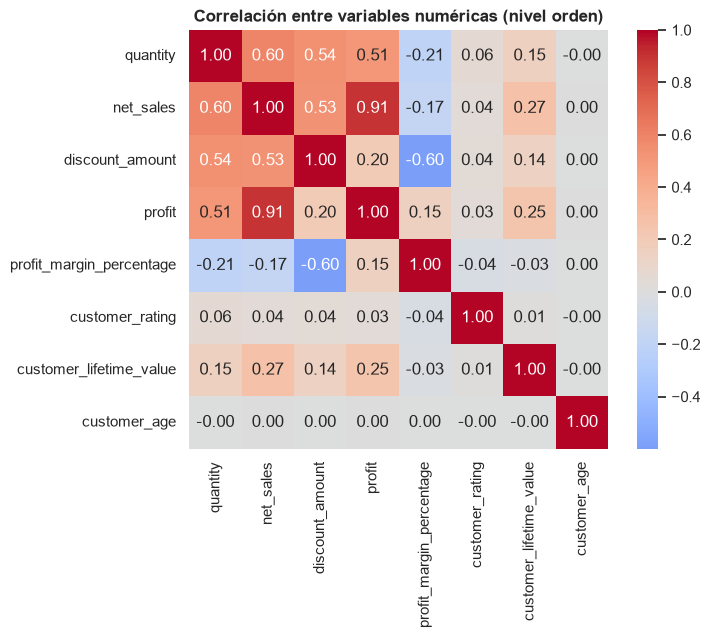

In [27]:
num_df = sales[['quantity', 'net_sales', 'discount_amount', 'profit', 'profit_margin_percentage',
                'customer_rating', 'customer_lifetime_value', 'customer_age']].copy()

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(num_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, square=True)
ax.set_title('Correlación entre variables numéricas (nivel orden)')
plt.tight_layout()
plt.show()


**Lectura rápida de las visualizaciones:**

- El catálogo está balanceado entre 15 categorías (68 a 91 productos c/u) — sin categorías dominantes.
- Ranking de productos más comprados y de ventas por categoría: útiles como **baseline de popularidad** (recomendar lo más comprado dentro de la categoría de interés del usuario).
- El **6.85% de devoluciones** y **6.08% de cancelaciones** son tasas razonables para e-commerce; no hay señales de error de carga.
- Los ratings están concentrados entre 3 y 4.5 (sesgo positivo típico de reseñas de e-commerce), coherente con que el 88% de las reseñas con sentimiento son "Positive"/"Neutral".
- La serie mensual de ventas no muestra saltos ni huecos raros en el rango 2021-2025 declarado.
- La correlación entre variables numéricas es baja/moderada en general — no hay redundancia fuerte que haga descartar features de entrada.

## 5. Hallazgos y decisiones para los próximos pasos

**Calidad de datos — decisiones de tratamiento (para el pipeline de feature engineering):**

1. `return_status`, `return_reason`, `campaign_name`, `coupon_code`: no imputar — recategorizar el nulo como una categoría más (`"No aplica"` / `"Sin campaña"` / `"Sin cupón"`).
2. `delivery_days`, `estimated_delivery_days`, `customer_rating`, `review_sentiment`: nulos ligados a `order_status != Completed` — mantenerlos como faltantes reales o crear un flag `tiene_reseña` en vez de imputar un valor.
3. Las 87 líneas de `order_items` con `(order_id, product_id)` repetido deben agregarse (sumar cantidades) antes de construir la matriz usuario-producto.
4. Para la matriz de interacciones, usar únicamente órdenes `Completed` y `Returned` (excluir `Cancelled`/`Pending`).
5. `customer_order_count` y `is_repeat_customer` están calculados a nivel cliente con el histórico **completo** (99.76% de los clientes ya figura como recurrente) — si se usan como features para predecir compra/recompra en un punto en el tiempo, hay que recalcularlos de forma acumulada *hasta la fecha de cada orden* para evitar data leakage.
6. Sesgo de datos simulados: la popularidad de producto es casi uniforme (no hay cola larga realista) — el baseline de popularidad va a tener menos fuerza discriminativa que en un dataset real; conviene aclararlo como limitación conocida en el informe.

**Próximos pasos (siguen dentro de Sprint 1):**
- Ingeniería de características: agregados por usuario (frecuencia, gasto promedio, categorías preferidas, recencia) y por producto (popularidad, rating promedio, tasa de devolución).
- Split respetando la secuencia temporal (train con órdenes más antiguas, test con las más recientes) para evitar fuga de información, tal como se definió en el plan de análisis.
- Armar el baseline de popularidad, el modelo no supervisado item-based (similitud coseno) y el modelo supervisado de probabilidad de compra/recompra.
